In [1]:
from typing import Literal
import torch

device: Literal["cuda", "cpu"] = "cuda" if torch.cuda.is_available() else "cpu"
if(device == "cuda"):
    print(torch.cuda.get_device_name())
else:
    print("cpu")

NVIDIA GeForce MX350


In [ ]:
from torch._tensor import Tensor
import pathlib
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader, Sampler

from datasets import Dataset as HuggingFaceDataset
from datasets import load_dataset

def preprocess(text: str = "") -> str:
    processed_text: str = ""
    for char in text.lower():
        if char in "abcdefghijklmnopqrstuvwxyz1234567890 ":
            processed_text += char
    return processed_text


vocabulary: set[str] = set()


def build_vocab(text: str = "") -> None:
    for token in text.split(sep=" "):
        vocabulary.add(token)


def tokenize(text: str = "", vocab: list[str] | None = None) -> list[int]:
    if vocab is None:
        vocab = []

    tokenized_text: list[int] = []
    for token in text.split(sep=" "):
        tokenized_text.append(vocab.index(token)+1 if token in vocab else 1)
        # padding - 0 (no need to append) =, 1 (oov token) -> passing vocab size to modal class vocab_size + 1(padding not included in vocab)
    return tokenized_text


class CustomDataset(Dataset):
    def __init__(self, mode: str = "train") -> None:
        self.mode = mode
        self.emotion: HuggingFaceDataset = load_dataset(
            path="dair-ai/emotion",
            split=mode,
            cache_dir=pathlib.Path() / "data" / mode,
            token=""
        )
        self.emotion.set_format(type="pandas")
        self.emotion = self.emotion[:]

        self.preprocessed_docs: pd.Series = self.emotion["text"].apply(preprocess)
        if self.mode == "train":
            self.preprocessed_docs.apply(build_vocab)
        self.vocabulary: list[str] = list(vocabulary)
        self.tokenized_docs: list[list[int]] = self.preprocessed_docs.apply(
            tokenize, args=(self.vocabulary,)
        ).to_list()
        self.docs_len: list[int] = [len(doc) for doc in self.tokenized_docs]

    def __len__(self) -> int:
        return self.emotion.shape[0]

    def __getitem__(
        self, index: int
    ) -> tuple[list[torch.Tensor], torch.Tensor]:
        features: Tensor = torch.tensor(self.tokenized_docs[index])
        label: Tensor = torch.tensor(self.emotion["label"].iloc[index])
        return features, label

train_dataset = CustomDataset(mode="train")
validation_dataset = CustomDataset(mode="validation")
test_dataset = CustomDataset(mode="test")

In [ ]:
from sklearn.utils import shuffle
from torch._C import Generator
import random

class LengthSortedBatchSampler(Sampler):
    def __init__(
        self: LengthSortedBatchSampler,
        docs_len: list[int] = [],
        shuffle: bool = True,
        seed: int = 42,
        step: int = 5,
    ):
        self.docs_len: list[int] = docs_len
        self.shuffle: bool = shuffle
        self.seed: int = seed
        self.epoch: int = 0
        self.step: int = step

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)

        batch_indexes: list[list[int]] = []
        for i in range(1, max(self.docs_len), self.step):
            current_batch: list[int] = []
            for j in range(len(self.docs_len)):
                if self.docs_len[j] >= i and self.docs_len[j] <= i + self.step - 1:
                    current_batch.append(j)

            if self.shuffle:
                rng.shuffle(current_batch)
            batch_indexes.append(current_batch)

        if self.shuffle:
            rng.shuffle(batch_indexes)

        return iter(batch_indexes) # The iterations is performed over list[int(indexes)] to you have to create list[list[int]]

    def __len__(self):
        return len(range(1, max(self.docs_len), self.step))


def pad_collete(batch):
    sequences, labels = zip(*batch) # Default collete function will do this and returns the features and labels to dataloader
    padded = torch.nn.utils.rnn.pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0,
    )
    return padded, torch.tensor(labels)

# Document length are different accross splits so creating seperate sampler objects
train_batch_sampler = LengthSortedBatchSampler(docs_len=train_dataset.docs_len, shuffle=True, seed=42)
validation_batch_sampler = LengthSortedBatchSampler(docs_len=validation_dataset.docs_len, shuffle=True, seed=42)
test_batch_sampler = LengthSortedBatchSampler(docs_len=test_dataset.docs_len, shuffle=True, seed=42)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_sampler=train_batch_sampler,
    collate_fn=pad_collete,
    pin_memory=True,
)
validation_dataloader = DataLoader(
    dataset=validation_dataset,
    batch_sampler=validation_batch_sampler,
    collate_fn=pad_collete,
    pin_memory=True,
)
test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_sampler=test_batch_sampler,
    collate_fn=pad_collete,
    pin_memory=True,
)

In [ ]:
import torch.nn as nn

class CustomModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, num_classes: int):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes

        self.embedding_layer = nn.Embedding(num_embeddings=self.vocab_size, embedding_dim=self.embedding_dim)
        self.rnn = nn.RNN(
            input_size=self.embedding_dim,
            hidden_size=12,
            num_layers=1,
            nonlinearity="tanh",
            bias=True,
            batch_first=True,
            dropout=0.0,
            bidirectional=False
        ) # Increase the RNN layer to boost the performance
        self.linear = nn.Linear(in_features=12, out_features=self.num_classes)
    
    def forward(self, features):
        embeddings = self.embedding_layer(features)
        hidden_states, context_vector = self.rnn(embeddings)
        logits = self.linear(context_vector.squeeze(0))

        return logits

In [5]:
output_classes: list[str] = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
learning_rate: float = 0.001
epochs: int = 500
criterion: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

model: CustomModel = CustomModel(vocab_size=len(vocabulary)+1, embedding_dim=64, num_classes=len(output_classes)).to(device=device)
optimizer: torch.optim.Adam = torch.optim.Adam(
    params=model.parameters(),
    lr=learning_rate
)

for i in range(epochs):
    total_loss: float = 0
    batch_size: int = 0

    for features, labels in train_dataloader:
        optimizer.zero_grad()
        features, labels = features.to(device), labels.to(device)
        logits = model(features)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size += len(features)
        total_loss += loss.item()
    
    if i % 50 == 0:
        print(f"Loss after {i} epochs: {total_loss / batch_size}")

Loss after 0 epochs: 0.0014570666310250576
Loss after 50 epochs: 0.0008497635672499116
Loss after 100 epochs: 0.0005555624488413546
Loss after 150 epochs: 0.00036325371642061767
Loss after 200 epochs: 0.0002675174030373041
Loss after 250 epochs: 0.00020895039585763436
Loss after 300 epochs: 0.00023520187393815317
Loss after 350 epochs: 0.0001889631611789433
Loss after 400 epochs: 0.0001318726387496378
Loss after 450 epochs: 0.00011896254349607283


Accuracy → 0.3549
Precision → 0.3633138835430145
Recall → 0.35488128662109375
F1-Score → 0.35773947834968567



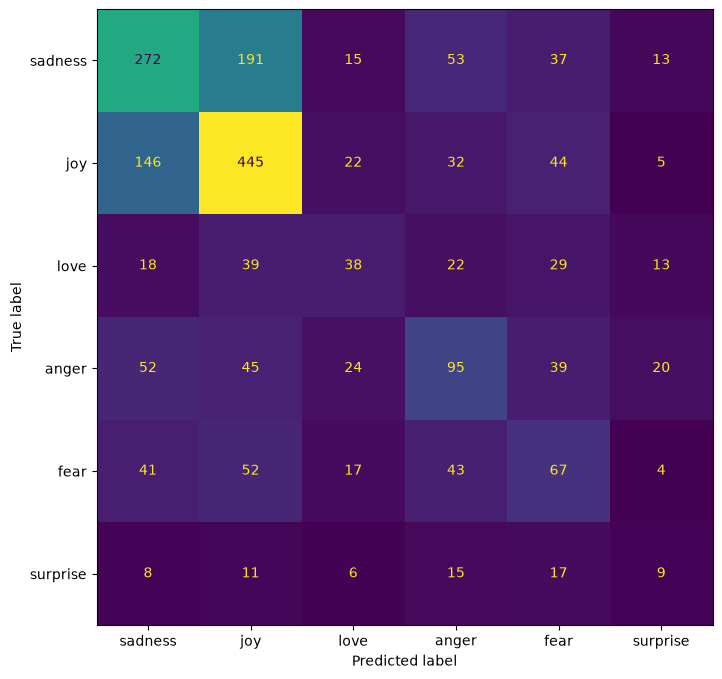

In [6]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix
)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
accuracy = MulticlassAccuracy(num_classes=6, average='macro').to(device)
precision = MulticlassPrecision(num_classes=6, average='macro').to(device)
recall = MulticlassRecall(num_classes=6, average='macro').to(device)
f1 = MulticlassF1Score(num_classes=6, average='macro').to(device)
confusion_matrix = MulticlassConfusionMatrix(num_classes=6).to(device)

with torch.no_grad():
    for features, labels in test_dataloader:
        features, labels = features.to(device), labels.to(device)
        logits = model(features)

        accuracy.update(logits, labels)
        precision.update(logits, labels)
        recall.update(logits, labels)
        f1.update(logits, labels)
        confusion_matrix.update(logits, labels)

test_accuracy = accuracy.compute()
test_precision = precision.compute()
test_recall = recall.compute()
test_f1 = f1.compute()
conf_matrix = confusion_matrix.compute()

print(f"Accuracy → {test_accuracy:.4f}")
print(f"Precision → {test_precision}")
print(f"Recall → {test_recall}")
print(f"F1-Score → {test_f1}", end="\n\n")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(19, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix.cpu().numpy(), 
    display_labels=output_classes
)
disp.plot(ax=ax, colorbar=False)
plt.show()